# Health Insurance Fraud Detection - Model Training
## Steps:
1. Install Libraries
2. Load Data
3. Exploratory Data Analysis (EDA)
4. Feature Engineering
5. Train Models
6. Evaluate Models
7. Improve Models
8. SHAP Explainability
9. Save Model

In [33]:
# STEP 1: Install Libraries
!pip install shap xgboost scikit-learn pandas matplotlib seaborn joblib


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [34]:
# STEP 2: Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import joblib
import os
import shap

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, roc_curve
from sklearn.utils.class_weight import compute_sample_weight
from xgboost import XGBClassifier

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)

print('All libraries loaded successfully!')

All libraries loaded successfully!


In [37]:
# STEP 3: Load Data
# Change path if needed
df = pd.read_csv(r"C:\Users\a\AppData\Local\Temp\bcd766a4-acfa-488c-a0d8-58be4c0e5ab8_archive (1).zip.ab8\synthetic_health_claims.csv")

print('Data loaded successfully!')
print('Total claims:', len(df))
print('Total columns:', len(df.columns))
print()
print('Fraud distribution:')
print(df['Is_Fraudulent'].value_counts())
print()
fraud_pct = df['Is_Fraudulent'].mean() * 100
print('Fraud percentage:', round(fraud_pct, 2), '%')

Data loaded successfully!
Total claims: 20100
Total columns: 30

Fraud distribution:
Is_Fraudulent
False    15089
True      5011
Name: count, dtype: int64

Fraud percentage: 24.93 %


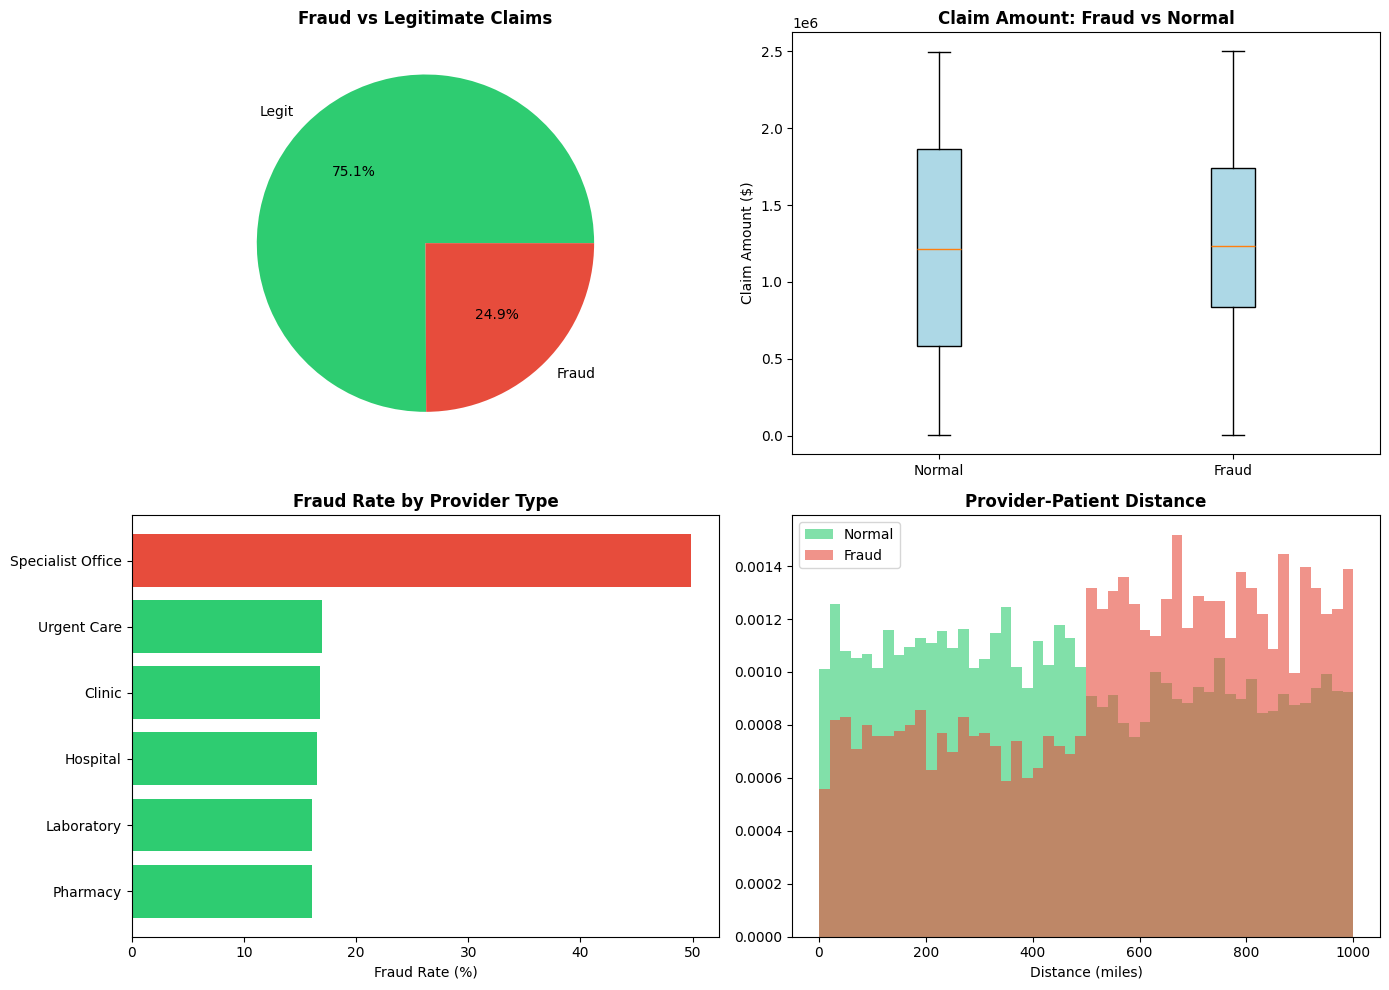

Average Normal claim:  $1227273.58
Average Fraud claim:   $1299777.4
Fraud claims are 1.1x higher!


In [38]:
# STEP 4: Exploratory Data Analysis (EDA)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Fraud Distribution
fraud_counts = df['Is_Fraudulent'].value_counts()
axes[0,0].pie(fraud_counts.values,
              labels=['Legit', 'Fraud'],
              autopct='%1.1f%%',
              colors=['#2ecc71', '#e74c3c'])
axes[0,0].set_title('Fraud vs Legitimate Claims', fontweight='bold')

# Plot 2: Claim Amount Comparison
fraud_amt = df[df['Is_Fraudulent'] == True]['Claim_Amount']
normal_amt = df[df['Is_Fraudulent'] == False]['Claim_Amount']
axes[0,1].boxplot([normal_amt, fraud_amt],
                  labels=['Normal', 'Fraud'],
                  patch_artist=True,
                  boxprops=dict(facecolor='lightblue'))
axes[0,1].set_title('Claim Amount: Fraud vs Normal', fontweight='bold')
axes[0,1].set_ylabel('Claim Amount ($)')

# Plot 3: Fraud Rate by Provider Type
provider_fraud = df.groupby('Provider_Type')['Is_Fraudulent'].mean() * 100
provider_fraud = provider_fraud.sort_values()
axes[1,0].barh(provider_fraud.index, provider_fraud.values,
               color=['#e74c3c' if x > 25 else '#2ecc71' for x in provider_fraud.values])
axes[1,0].set_title('Fraud Rate by Provider Type', fontweight='bold')
axes[1,0].set_xlabel('Fraud Rate (%)')

# Plot 4: Distance Distribution
fraud_dist = df[df['Is_Fraudulent'] == True]['Provider_Patient_Distance_Miles']
normal_dist = df[df['Is_Fraudulent'] == False]['Provider_Patient_Distance_Miles']
axes[1,1].hist(normal_dist, bins=50, alpha=0.6, color='#2ecc71', label='Normal', density=True)
axes[1,1].hist(fraud_dist, bins=50, alpha=0.6, color='#e74c3c', label='Fraud', density=True)
axes[1,1].set_title('Provider-Patient Distance', fontweight='bold')
axes[1,1].set_xlabel('Distance (miles)')
axes[1,1].legend()

plt.tight_layout()
plt.savefig('plot_01_eda.png', dpi=150, bbox_inches='tight')
plt.show()

print('Average Normal claim:  $' + str(round(normal_amt.mean(), 2)))
print('Average Fraud claim:   $' + str(round(fraud_amt.mean(), 2)))
print('Fraud claims are ' + str(round(fraud_amt.mean()/normal_amt.mean(), 1)) + 'x higher!')

In [39]:
# STEP 5: Feature Engineering
df_model = df.copy()

# Convert dates
df_model['Claim_Date'] = pd.to_datetime(df_model['Claim_Date'])
df_model['Service_Date'] = pd.to_datetime(df_model['Service_Date'])
df_model['Policy_Expiration_Date'] = pd.to_datetime(df_model['Policy_Expiration_Date'])

# New features
df_model['days_claim_to_service'] = (df_model['Claim_Date'] - df_model['Service_Date']).dt.days
df_model['days_to_policy_expiry'] = (df_model['Policy_Expiration_Date'] - df_model['Claim_Date']).dt.days
df_model['amount_per_procedure'] = df_model['Claim_Amount'] / (df_model['Number_of_Procedures'] + 1)
df_model['claim_to_deductible_ratio'] = df_model['Claim_Amount'] / (df_model['Deductible_Amount'] + 1)
df_model['is_far_provider'] = (df_model['Provider_Patient_Distance_Miles'] > 500).astype(int)
df_model['high_claim_patient'] = (df_model['Number_of_Previous_Claims_Patient'] > 5).astype(int)
df_model['high_claim_provider'] = (df_model['Number_of_Previous_Claims_Provider'] > 20).astype(int)

# Label Encoding - only columns we actually use
categorical_columns = [
    'Patient_Gender',
    'Provider_Type', 'Provider_Specialty',
    'Diagnosis_Code', 'Admission_Type', 'Discharge_Type', 'Service_Type'
]
label_encoders = {}
for col in categorical_columns:
    le = LabelEncoder()
    df_model[col + '_encoded'] = le.fit_transform(df_model[col].astype(str))
    label_encoders[col] = le

# Define features and target
features = [
    'Claim_Amount', 'Deductible_Amount', 'CoPay_Amount',
    'Patient_Age', 'Patient_Gender_encoded',
    'Number_of_Previous_Claims_Patient',
    'Provider_Type_encoded', 'Provider_Specialty_encoded',
    'Number_of_Previous_Claims_Provider',
    'Diagnosis_Code_encoded', 'Number_of_Procedures',
    'Admission_Type_encoded', 'Discharge_Type_encoded',
    'Length_of_Stay_Days', 'Service_Type_encoded',
    'Provider_Patient_Distance_Miles',
    'days_claim_to_service', 'days_to_policy_expiry',
    'amount_per_procedure', 'claim_to_deductible_ratio',
    'is_far_provider', 'high_claim_patient', 'high_claim_provider',
    'Claim_Submitted_Late'
]

X = df_model[features]
y = df_model['Is_Fraudulent'].astype(int)

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print('Features ready:', len(features))
print('Training set:', X_train.shape[0], 'claims')
print('Testing set:', X_test.shape[0], 'claims')

Features ready: 24
Training set: 16080 claims
Testing set: 4020 claims


In [40]:
# STEP 6: Train Models

# Sample weights - give Fraud more importance
weights = compute_sample_weight(class_weight='balanced', y=y_train)

# Random Forest
print('Training Random Forest...')
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=12,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)
print('Random Forest done!')

# XGBoost
print('Training XGBoost...')
xgb_model = XGBClassifier(
    n_estimators=500,
    max_depth=8,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=3,
    random_state=42,
    eval_metric='logloss',
    verbosity=0
)
xgb_model.fit(X_train, y_train, sample_weight=weights)
print('XGBoost done!')

Training Random Forest...


Random Forest done!
Training XGBoost...
XGBoost done!


Total Fraud cases in test set: 1002

Random Forest:
  Caught Fraud:       858 out of 1002
  Missed Fraud:       144
  False Alarms:       758
  Detection Rate:     85.6%
  AUC Score:          0.8649

XGBoost:
  Caught Fraud:       805 out of 1002
  Missed Fraud:       197
  False Alarms:       518
  Detection Rate:     80.3%
  AUC Score:          0.8639



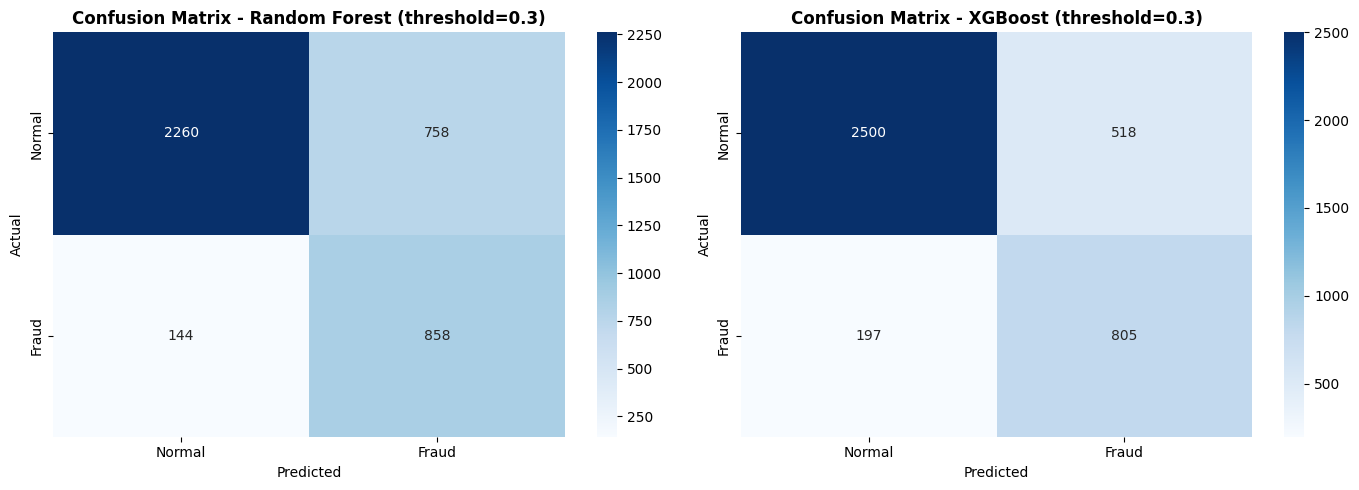

In [41]:
# STEP 7: Evaluate Models with Threshold = 0.3

rf_prob = rf_model.predict_proba(X_test)[:, 1]
xgb_prob = xgb_model.predict_proba(X_test)[:, 1]

total_fraud = y_test.sum()
print('Total Fraud cases in test set:', total_fraud)
print()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (model_name, prob) in zip(axes, [('Random Forest', rf_prob), ('XGBoost', xgb_prob)]):
    
    # Use threshold 0.3
    pred = (prob >= 0.3).astype(int)
    cm = confusion_matrix(y_test, pred)
    tn, fp, fn, tp = cm.ravel()
    
    # Plot
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Normal', 'Fraud'],
                yticklabels=['Normal', 'Fraud'])
    ax.set_title('Confusion Matrix - ' + model_name + ' (threshold=0.3)', fontweight='bold')
    ax.set_ylabel('Actual')
    ax.set_xlabel('Predicted')
    
    # Print results
    detection_rate = round(tp / total_fraud * 100, 1)
    auc = round(roc_auc_score(y_test, prob), 4)
    print(model_name + ':')
    print('  Caught Fraud:       ' + str(tp) + ' out of ' + str(total_fraud))
    print('  Missed Fraud:       ' + str(fn))
    print('  False Alarms:       ' + str(fp))
    print('  Detection Rate:     ' + str(detection_rate) + '%')
    print('  AUC Score:          ' + str(auc))
    print()

plt.tight_layout()
plt.savefig('plot_02_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

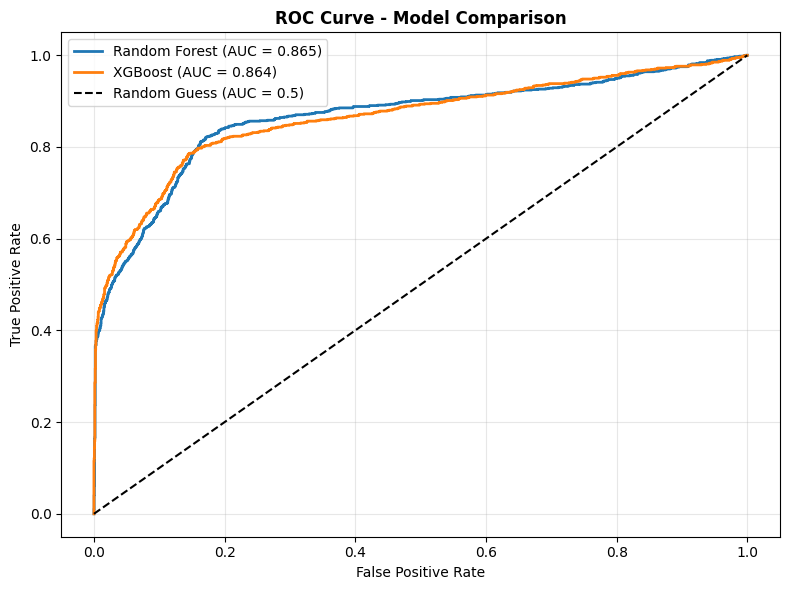

In [42]:
# STEP 8: ROC Curve - Model Comparison

plt.figure(figsize=(8, 6))

for model_name, prob in [('Random Forest', rf_prob), ('XGBoost', xgb_prob)]:
    fpr, tpr, _ = roc_curve(y_test, prob)
    auc = round(roc_auc_score(y_test, prob), 3)
    plt.plot(fpr, tpr, linewidth=2, label=model_name + ' (AUC = ' + str(auc) + ')')

plt.plot([0, 1], [0, 1], 'k--', label='Random Guess (AUC = 0.5)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Model Comparison', fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('plot_03_roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()

Calculating SHAP values... (may take a minute)


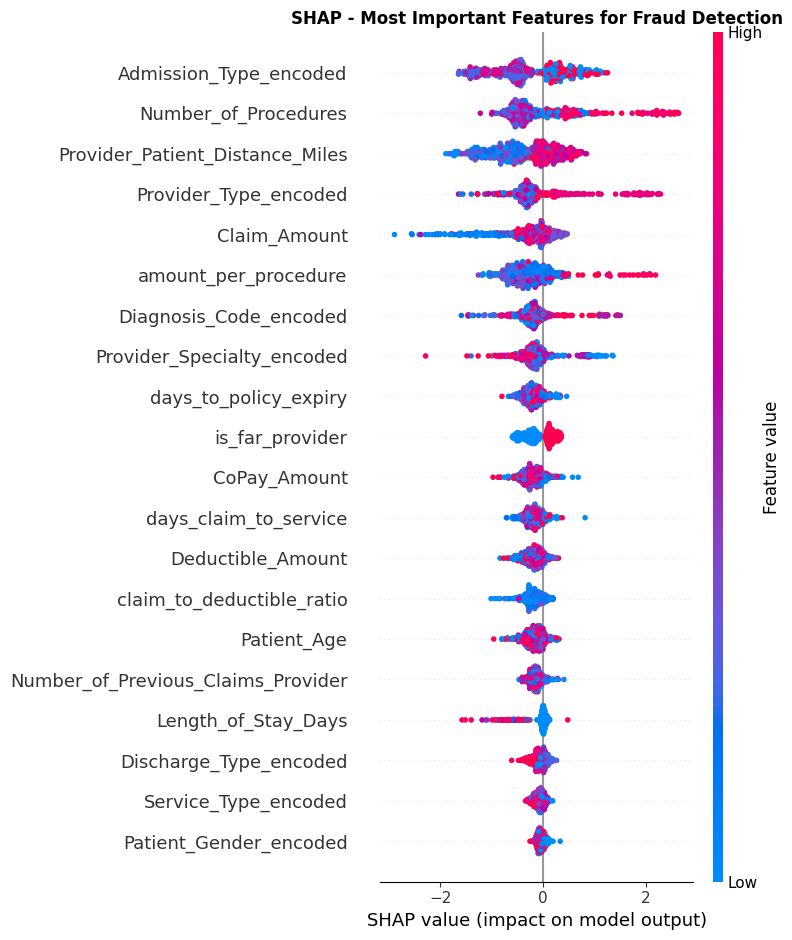

Done!


In [43]:
# STEP 9: SHAP - Why did the model flag this claim as Fraud?

print('Calculating SHAP values... (may take a minute)')
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test[:500])

plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test[:500], feature_names=features, show=False)
plt.title('SHAP - Most Important Features for Fraud Detection', fontweight='bold')
plt.tight_layout()
plt.savefig('plot_04_shap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Done!')

In [44]:
# STEP 10: Save Models

# STEP 10: Save Models
os.makedirs('models', exist_ok=True)
joblib.dump(xgb_model, 'models/xgb_fraud_model.pkl')
joblib.dump(rf_model, 'models/rf_fraud_model.pkl')
joblib.dump(label_encoders, 'models/label_encoders.pkl')
joblib.dump(features, 'models/features_list.pkl')

['models/features_list.pkl']

In [45]:
# STEP 11: Final Summary

print('=' * 50)
print('FINAL RESULTS SUMMARY')
print('=' * 50)
print('Total Fraud cases in test set: ' + str(int(y_test.sum())))
print()

for model_name, prob in [('Random Forest', rf_prob), ('XGBoost', xgb_prob)]:
    pred = (prob >= 0.3).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, pred).ravel()
    detection_rate = round(tp / y_test.sum() * 100, 1)
    auc = round(roc_auc_score(y_test, prob), 3)
    
    print(model_name + ':')
    print('  Caught Fraud:    ' + str(tp) + ' (' + str(detection_rate) + '%)')
    print('  Missed Fraud:    ' + str(fn))
    print('  False Alarms:    ' + str(fp))
    print('  AUC Score:       ' + str(auc))
    print()

FINAL RESULTS SUMMARY
Total Fraud cases in test set: 1002

Random Forest:
  Caught Fraud:    858 (85.6%)
  Missed Fraud:    144
  False Alarms:    758
  AUC Score:       0.865

XGBoost:
  Caught Fraud:    805 (80.3%)
  Missed Fraud:    197
  False Alarms:    518
  AUC Score:       0.864



In [47]:
# ===== Test on New Claim =====

loaded_model = joblib.load('models/xgb_fraud_model.pkl')
loaded_encoders = joblib.load('models/label_encoders.pkl')
loaded_features = joblib.load('models/features_list.pkl')

suspicious_case = {
    'Claim_Amount': 1000000.0,
    'Patient_Age': 20,
    'Patient_Gender': 'Male',
    'Provider_Type': 'Specialist Office',
    'Provider_Specialty': 'Cardiology',
    'Diagnosis_Code': 'I21',
    'Number_of_Procedures': 1,
    'Admission_Type': 'Elective',
    'Discharge_Type': 'Deceased',
    'Length_of_Stay_Days': 0,
    'Service_Type': 'Outpatient',
    'Deductible_Amount': 100,
    'CoPay_Amount': 10,
    'Number_of_Previous_Claims_Patient': 80,
    'Number_of_Previous_Claims_Provider': 50,
    'Provider_Patient_Distance_Miles': 800.0,
    'Claim_Submitted_Late': True,
    'Claim_Date': '2024-06-01',
    'Service_Date': '2023-01-01',
    'Policy_Expiration_Date': '2025-01-01'
}

df_claim = pd.DataFrame([suspicious_case])
df_claim['Claim_Date'] = pd.to_datetime(df_claim['Claim_Date'])
df_claim['Service_Date'] = pd.to_datetime(df_claim['Service_Date'])
df_claim['Policy_Expiration_Date'] = pd.to_datetime(df_claim['Policy_Expiration_Date'])

df_claim['days_claim_to_service'] = (df_claim['Claim_Date'] - df_claim['Service_Date']).dt.days
df_claim['days_to_policy_expiry'] = (df_claim['Policy_Expiration_Date'] - df_claim['Claim_Date']).dt.days
df_claim['amount_per_procedure'] = df_claim['Claim_Amount'] / (df_claim['Number_of_Procedures'] + 1)
df_claim['claim_to_deductible_ratio'] = df_claim['Claim_Amount'] / (df_claim['Deductible_Amount'] + 1)
df_claim['is_far_provider'] = (df_claim['Provider_Patient_Distance_Miles'] > 500).astype(int)
df_claim['high_claim_patient'] = (df_claim['Number_of_Previous_Claims_Patient'] > 5).astype(int)
df_claim['high_claim_provider'] = (df_claim['Number_of_Previous_Claims_Provider'] > 20).astype(int)

categorical_cols = [
    'Patient_Gender', 'Provider_Type', 'Provider_Specialty',
    'Diagnosis_Code', 'Admission_Type', 'Discharge_Type', 'Service_Type'
]
for col in categorical_cols:
    le = loaded_encoders[col]
    val = df_claim[col].astype(str).values[0]
    if val in le.classes_:
        df_claim[col + '_encoded'] = le.transform([val])[0]
    else:
        df_claim[col + '_encoded'] = 0

X_new = df_claim[loaded_features]
fraud_prob = loaded_model.predict_proba(X_new)[0][1]
is_fraud = fraud_prob >= 0.3

print('=' * 40)
print('CLAIM ANALYSIS RESULT')
print('=' * 40)
print('Fraud Probability: ' + str(round(fraud_prob * 100, 1)) + '%')
print('Decision:          ' + ('FRAUD' if is_fraud else 'Normal'))
if fraud_prob > 0.8:
    print('Risk Level:        Very High Risk')
elif fraud_prob > 0.6:
    print('Risk Level:        High Risk')
elif fraud_prob > 0.3:
    print('Risk Level:        Medium Risk')
else:
    print('Risk Level:        Low Risk')
print()
print('Claim Amount:             $' + str(suspicious_case['Claim_Amount']))
print('Distance:                 ' + str(suspicious_case['Provider_Patient_Distance_Miles']) + ' miles')
print('Length of Stay:           ' + str(suspicious_case['Length_of_Stay_Days']) + ' days')
print('Discharge Type:           ' + str(suspicious_case['Discharge_Type']))
print('Submitted Late:           ' + str(suspicious_case['Claim_Submitted_Late']))
print('Previous Claims Patient:  ' + str(suspicious_case['Number_of_Previous_Claims_Patient']))
print('Previous Claims Provider: ' + str(suspicious_case['Number_of_Previous_Claims_Provider']))

CLAIM ANALYSIS RESULT
Fraud Probability: 31.3%
Decision:          FRAUD
Risk Level:        Medium Risk

Claim Amount:             $1000000.0
Distance:                 800.0 miles
Length of Stay:           0 days
Discharge Type:           Deceased
Submitted Late:           True
Previous Claims Patient:  80
Previous Claims Provider: 50
